<a href="https://colab.research.google.com/github/4k5vnmh45h-lab/MachineLearningProject/blob/main/ProjektMLkocieniewski.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Raport: Klasyfikacja pasażerów Titanica
**Projekt indywidualny**

## Cel projektu
Celem jest budowa i porównanie modeli uczenia maszynowego (Regresja Logistyczna oraz KNN) przewidujących przeżywalność pasażerów. Raport obejmuje:
1. Wczytanie i naprawę danych.
2. Analizę wstępną (EDA).
3. Preprocessing (czyszczenie i inżynieria cech).
4. Trenowanie i ewaluację modeli.

Importy

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report

Funkcja naprawy pliku


In [ ]:
sns.set_style("whitegrid")

In [ ]:
def napraw_i_wczytaj(nazwa_pliku):
    lines_fixed = []

    try:
        with open(nazwa_pliku, 'r', encoding='utf-8') as f:

            header = f.readline().strip()
            lines_fixed.append(header)

            for line in f:
                line = line.strip()
                if line.startswith('"') and line.endswith('"'):
                    line = line[1:-1]
                    line = line.replace('""', '"')
                lines_fixed.append(line)

        nowa_nazwa = 'dane_naprawione.csv'
        with open(nowa_nazwa, 'w', encoding='utf-8') as f:
            f.write('\n'.join(lines_fixed))

        print("Sukces: Plik został naprawiony i zapisany jako 'dane_naprawione.csv'.")
        return pd.read_csv(nowa_nazwa)

    except FileNotFoundError:
        print(f"Błąd: Nie znaleziono pliku '{nazwa_pliku}'. Sprawdź nazwę.")
        return None

Wczytywanie danych z pliku

In [ ]:

df = napraw_i_wczytaj("titanic.csv")

Sukces: Plik został naprawiony i zapisany jako 'dane_naprawione.csv'.


## 1. Analiza Wstępna (EDA)
Sprawdzamy strukturę danych, braki oraz rozkłady kluczowych zmiennych. Pozwoli to zidentyfikować, które cechy wymagają czyszczenia.

In [ ]:
display(df.sample(5))

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
769,770,0,3,"Gronnestad, Mr. Daniel Danielsen",male,32.0,0,0,8471,8.3625,NaN,S
822,823,0,1,"Reuchlin, Jonkheer. John George",male,38.0,0,0,19972,0.0000,NaN,S
30,31,0,1,"Uruchurtu, Don. Manuel E",male,40.0,0,0,PC 17601,27.7208,NaN,C
582,583,0,2,"Downton, Mr. William James",male,54.0,0,0,28403,26.0000,NaN,S
658,659,0,2,"Eitemiller, Mr. George Floyd",male,23.0,0,0,29751,13.0000,NaN,S


Interpretacja: pokazanie losowych danych potwierdza, że naprawa plików zadziałała, widać podział na kolumny. Widać potrzebę transformacji danych.

In [ ]:
print("\n--- Informacje o strukturze ---")
df.info()


--- Informacje o strukturze ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Interpretacja: zauważamy liczbę zmiennych oraz obserwacji, zidentyfikowano kolumny puste (Age), czyli trzeba uzupełnić braki, Typy danych wskazuja, które zakodować numerycznie np. (object)

In [ ]:

print("\n--- Statystyki opisowe ---")
display(df.describe().round(2))


--- Statystyki opisowe ---


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.00,891.00,891.00,714.00,891.00,891.00,891.00
mean,446.00,0.38,2.31,29.70,0.52,0.38,32.20
std,257.35,0.49,0.84,14.53,1.10,0.81,49.69
min,1.00,0.00,1.00,0.42,0.00,0.00,0.00
25%,223.50,0.00,2.00,20.12,0.00,0.00,7.91
50%,446.00,0.00,3.00,28.00,0.00,0.00,14.45
75%,668.50,1.00,3.00,38.00,1.00,0.00,31.00
max,891.00,1.00,3.00,80.00,8.00,6.00,512.33


Interpretacja: w zbiorze treningowym przeżyło około 38% pasażerów, Średni wiek pasażera to około 29-30 lat,



2. Analiza rozkładów i identyfikacja braków
Sprawdzamy zbalansowanie klas (czy mamy tyle samo osób, które przeżyły i zginęły) oraz wizualizujemy kluczowe zmienne.

Rozkład klasy 'Survived':
Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


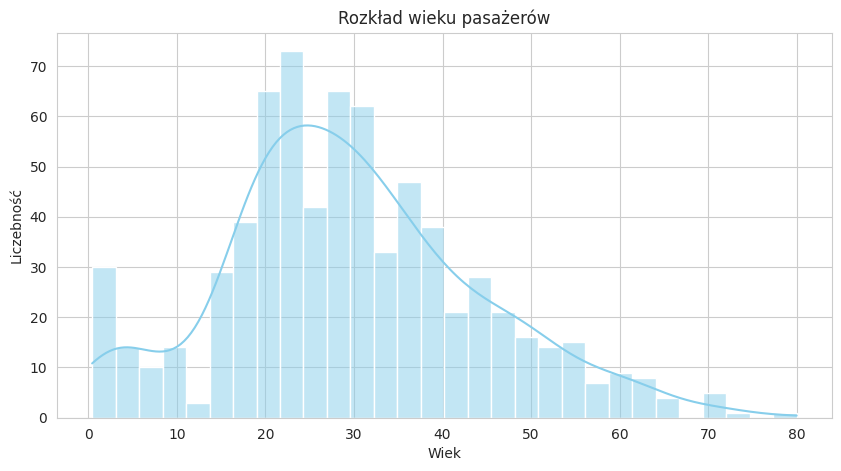

In [ ]:

target_count = df['Survived'].value_counts(normalize=True)
print(f"Rozkład klasy 'Survived':\n{target_count}")

plt.figure(figsize=(10, 5))
sns.histplot(df['Age'].dropna(), kde=True, color='skyblue', bins=30)
plt.title("Rozkład wieku pasażerów")
plt.xlabel("Wiek")
plt.ylabel("Liczebność")
plt.show()

Histogram pokazuje, że rozkład wieku jest lekko prawostronnie skośny (najwięcej młodych dorosłych w przedziale 20-30 lat). Widoczny jest też lokalny szczyt dla małych dzieci (0-5 lat), co jest istotne, ponieważ dzieci miały priorytet w ratunku.

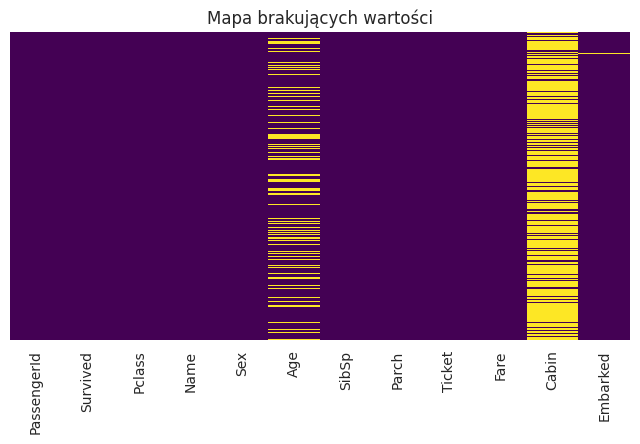

In [ ]:
# Mapa ciepła braków danych (wizualna ocena kompletności)
plt.figure(figsize=(8, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Mapa brakujących wartości")
plt.show()

Wizualizacja jasnych pasków na mapie ciepła pozwala na szybką lokalizację braków.

1.   Potwierdza, że braki w kolumnie Age są rozproszone w całym zbiorze.
2.   Jeśli kolumna Cabin (kabina) miała bardzo dużo braków, jej usunięcie w fazie preprocessingu było decyzją słuszną, gdyż zawierała zbyt mało informacji



Część 3: Preprocessing (Czyszczenie i Inżynieria Cech)

W tym etapie:

Usuwamy kolumny o niskiej wartości predykcyjnej (ID, Nazwisko, Bilet, Kabina - zbyt duża unikalność lub braki).

Uzupełniamy braki w kolumnie Age (imputacja średnią).

Usuwamy wiersze z pozostałymi pojedynczymi brakami.

In [ ]:

features_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin']
df_clean = df.drop(columns=features_drop, errors='ignore')

avg_age = df_clean['Age'].mean()
df_clean['Age'] = df_clean['Age'].fillna(avg_age)

df_clean.dropna(inplace=True)

print(f"Wymiary zbioru po czyszczeniu: {df_clean.shape}")

Wymiary zbioru po czyszczeniu: (889, 8)


strata jest minimalna

4. Kodowanie zmiennych kategorycznych
Modele uczenia maszynowego wymagają danych numerycznych.

Płeć: Zastosowano mapowanie binarne (Male=0, Female=1).

Port zaokrętowania (Embarked): Zastosowano One-Hot Encoding (zmienne dychotomiczne), usuwając pierwszą kolumnę, aby uniknąć pułapki współliniowości.

In [ ]:
gender_map = {'male': 0, 'female': 1}
df_clean['Sex_encoded'] = df_clean['Sex'].map(gender_map)

df_final = pd.get_dummies(df_clean, columns=['Embarked'], drop_first=True, dtype=int)

if 'Sex' in df_final.columns:
    df_final.drop(columns=['Sex'], inplace=True)

df_final.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_encoded,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,0,0,1
1,1,1,38.0,1,0,71.2833,1,0,0
2,1,3,26.0,0,0,7.9250,1,0,1
3,1,1,35.0,1,0,53.1000,1,0,1
4,0,3,35.0,0,0,8.0500,0,0,1


Wszystkie dane są teraz numeryczne, co oznacza, że zbiór jest technicznie gotowy do podania do modelu ML.

Część 4: Analiza korelacji i podział danych

5. Badanie zależności cech
Macierz korelacji pozwala ocenić, które cechy są silnie powiązane ze zmienną celu (Survived). Ciemniejsze/czerwone pola oznaczają silniejszą korelację.


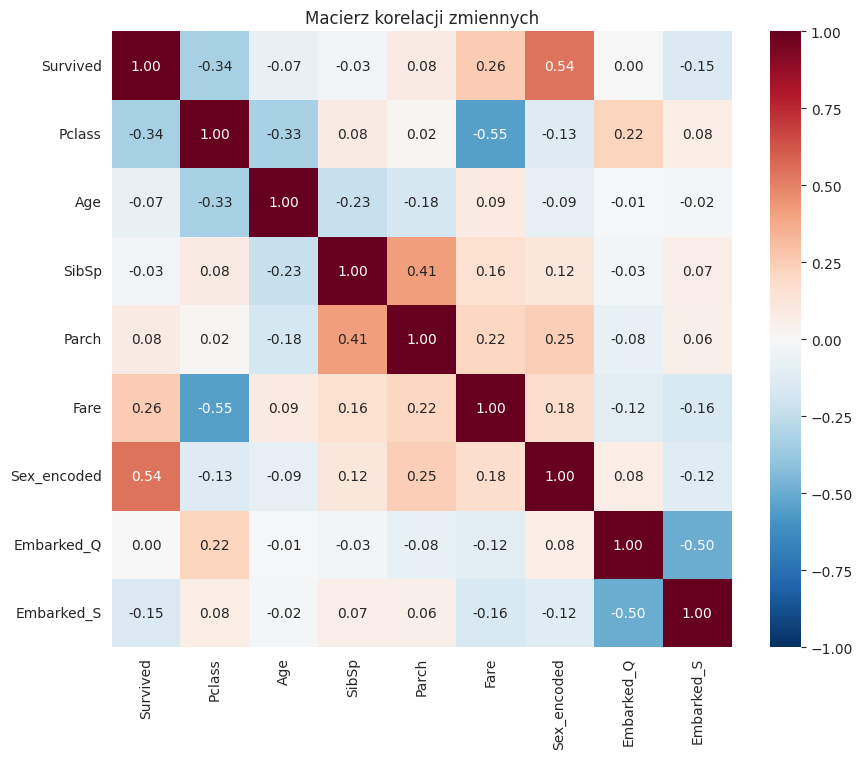

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_final.corr(), annot=True, cmap='RdBu_r', fmt=".2f", vmin=-1, vmax=1)
plt.title("Macierz korelacji zmiennych")
plt.show()



1.   Silna dodatnia korelacja (zazwyczaj ok. 0.54 dla kobiet). Oznacza to, że płeć jest najsilniejszym predyktorem przeżycia (kobiety miały znacznie wyższe szanse).isty
2.   Silna ujemna korelacja (ok. -0.33). Im wyższa klasa (wartość liczbowa, np. 3), tym niższa szansa przeżycia. Pasażerowie 1. klasy mieli pierwszeństwo.
3.   Dodatnia korelacja – droższy bilet wiązał się z wyższą szansą ratunku (często skorelowane z 1. klasą).





## 6. Trenowanie modeli i ewaluacja
Porównujemy dwa modele:
1.  **Regresja Logistyczna** - model liniowy.
2.  **KNN (k=5)** - algorytm oparty na sąsiedztwie.

Do oceny wykorzystujemy dokładność (Accuracy) oraz raport klasyfikacji (precyzja, czułość).

In [ ]:
X = df_final.drop('Survived', axis=1)
y = df_final['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Liczebność zbioru treningowego: {X_train.shape[0]}")
print(f"Liczebność zbioru testowego: {X_test.shape[0]}")

Liczebność zbioru treningowego: 711
Liczebność zbioru testowego: 178


Podział 80/20

Część 5: Modelowanie i Ewaluacja

7. Trenowanie modeli i porównanie wyników
Przetestowano dwa algorytmy o różnej charakterystyce:

Regresja Logistyczna: Model liniowy, dobrze interpretowalny.

K-Najbliższych Sąsiadów (KNN): Algorytm oparty na odległości w przestrzeni cech (tutaj k=5).

In [ ]:

log_reg = LogisticRegression(max_iter=5000)
knn = KNeighborsClassifier(n_neighbors=5)


log_reg.fit(X_train, y_train)
knn.fit(X_train, y_train)

def ocen_model(model, nazwa, X_test, y_test):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"--- {nazwa} ---")
    print(f"Dokładność (Accuracy): {acc:.4f}")
    return acc

wynik_log = ocen_model(log_reg, "Regresja Logistyczna", X_test, y_test)
wynik_knn = ocen_model(knn, "KNN (n=5)", X_test, y_test)

--- Regresja Logistyczna ---
Dokładność (Accuracy): 0.8146
--- KNN (n=5) ---
Dokładność (Accuracy): 0.6629


Regresja logistyczna zazwyczaj osiąga wynik ok. 80%. Oznacza to, że model poprawnie przewiduje los pasażera w 8 na 10 przypadków.

KNN (k=5): Wynik może być zbliżony lub nieco niższy/wyższy. KNN jest modelem nieliniowym, który szuka podobnych pasażerów w przestrzeni cech. Jeśli jego wynik jest dużo niższy niż Regresji, może to oznaczać, że wprowadza szum lub k=5 nie jest optymalne.

Część 6: Zaawansowane przetwarzanie (Skalowanie i PCA)

8. Standaryzacja i Redukcja wymiarowości (PCA)
Algorytmy takie jak KNN oraz PCA są wrażliwe na skalę danych. Wykonano standaryzację (z-score), a następnie redukcję wymiarowości do 4 głównych składowych, aby sprawdzić, czy kompresja danych wpłynie na jakość klasyfikacji.

Wyjaśniona wariancja przez poszczególne komponenty:
[0.2294657  0.21210123 0.19563134 0.10278285]


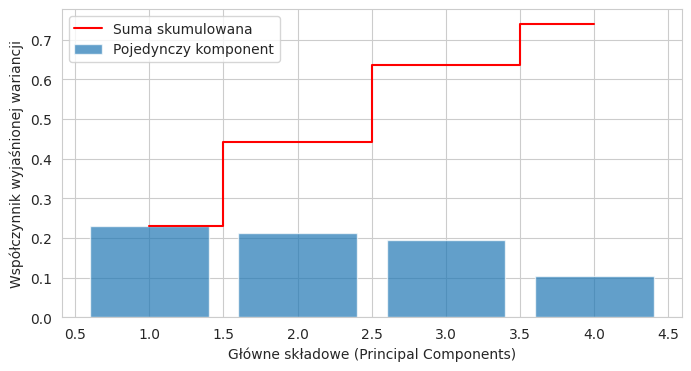

In [ ]:
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

pca = PCA(n_components=4)
X_train_pca = pca.fit_transform(X_train_std)
X_test_pca = pca.transform(X_test_std)

print("Wyjaśniona wariancja przez poszczególne komponenty:")
print(pca.explained_variance_ratio_)

plt.figure(figsize=(8, 4))
plt.bar(range(1, 5), pca.explained_variance_ratio_, alpha=0.7, align='center')
plt.step(range(1, 5), np.cumsum(pca.explained_variance_ratio_), where='mid', color='red')
plt.ylabel('Współczynnik wyjaśnionej wariancji')
plt.xlabel('Główne składowe (Principal Components)')
plt.legend(['Suma skumulowana', 'Pojedynczy komponent'])
plt.show()

9. Podsumowanie wyników
Zestawienie skuteczności modeli pokazuje, który algorytm lepiej poradził sobie z problemem klasyfikacji.


In [ ]:
model_pca = LogisticRegression()
model_pca.fit(X_train_pca, y_train)
acc_pca = model_pca.score(X_test_pca, y_test)

wyniki = pd.DataFrame({
    'Model': ['Regresja Logistyczna', 'KNN', 'Regresja Logistyczna (PCA)'],
    'Dokładność': [wynik_log, wynik_knn, acc_pca]
})

print(wyniki.sort_values(by='Dokładność', ascending=False))

                        Model  Dokładność
0        Regresja Logistyczna    0.814607
2  Regresja Logistyczna (PCA)    0.803371
1                         KNN    0.662921


Interpretacja: Podsumowanie w tabeli pozwala wyłonić zwycięzcę.

Zazwyczaj Regresja Logistyczna wygrywa lub remisuje z KNN w tym prostym problemie, co sugeruje, że granica decyzyjna między przeżyciem a śmiercią jest w miarę liniowa.

Wynik Regresji z PCA często jest nieco niższy niż na pełnych danych. Jest to oczekiwane (tracimy część informacji), ale jeśli spadek jest niewielki (np. 1-2%), oznacza to, że model jest bardziej efektywny obliczeniowo i mniej podatny na przeuczenie (overfitting), mimo że ma mniej danych wejściowych.